# STA 9797 Project by Tyler Lara
## The DRAM Shortage
In late 2024, a DRAM shortage appeared, with supply constraints tightening in the semiconductor memory market. The main driver of this was the rapid expansion of large scale AI models and infrastructure, which requires a massive amount of specialized memory called High Bandwidth Memory (HBM). While it is functionally different from Dynamic Random Access Memory (DRAM) and NAND flash memory used in the majority of consumer products, the same manufacturers produce them.

In [ ]:
!pip install -q linearmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pathlib
import statsmodels.api as sm
from linearmodels import PanelOLS
import scipy
import seaborn as sns
import os
import glob
import json
import statsmodels.formula.api as smf

# Problem: DRAM shortage

Since major memory manufacturers  (Samsung, SK Hynix, and Micron) shifted production from towards HBM due to higher profit margins, the supply of consumer grade RAM has become increasingly constrained.
As a result, technology firms that rely on DRAM for their consumer grade products like Apple, Dell, HP, AMD, and NVIDIA, have higher component costs and supply constraints. The impact of these price changes may differ across consumer groups. For example price sensitive consumers tend to purchase older or lower capacity memory options (e.g., DDR4 or 8-16 GB), while less price sensitive consumers are more likely to seek newer and higher capacity memory(e.g., DDR5 or ≥32 GB).

<br>
<br>

Did the global DRAM shortage raise the relative cost of newer and higher capacity RAM disproportionately relative to older or lower-capacity alternatives?


---
### **Hypothesis:**

$$
H_0: \beta=0
$$
$$
H_a: \beta>0
$$
*$\beta$ measures the additional price change caused by the shortage for high newer/higher capaticty products compared to older/lower capacity products*
### **Target Metric:**
Price per gigabyte($/GB)

### **Data Collection**
The data is sourced from Kaggle, containing approximately 10,000 records observations of memory kits from 2024 to 2026. The data is synthetic, but is designed to reflect real conditions in the consumer memory market. Key variables include price per gigabyte, memory generation (DDR4 vs. DDR5), total capacity, region, and time.

https://www.kaggle.com/datasets/moaz1911/ultimate-memory-crisis-hardware-market-dynamics/data

# 1: Data Preperation


In [ ]:
# Dataset: ultimate-memory-crisis-hardware-market-dynamics
# File used: Ultimate_Memory_Shortage_Crisis_Dataset_10k.csv

import kagglehub

path = kagglehub.dataset_download("moaz1911/ultimate-memory-crisis-hardware-market-dynamics")

df = pd.read_csv(os.path.join(path, "Ultimate_Memory_Shortage_Crisis_Dataset_10k.csv"))

df.head()

Using Colab cache for faster access to the 'ultimate-memory-crisis-hardware-market-dynamics' dataset.


,kit_id,brand,model_name,timestamp,region,generation,form_factor,capacity_gb,module_count,is_ecc,...,latency_value_index,speed_premium_ratio,price_per_gb,price_usd,market_segment,recommended_usage,price_status,global_inventory_weeks,fab_utilization_rate,gpu_hbm_trend_gb
0,MPN-000000,Mushkin,Mushkin DDR5 6400MT/s,2026-05-13,EMEA,DDR5,DIMM,512,2,False,...,415610.03,8.8352,61.85,31665.53,Enterprise/AI,AI / Data Science,Shortage-Inflated,5.98,0.8543,236.85
1,MPN-000001,Patriot,Patriot DDR6 (Preview) 16000MT/s,2025-09-15,Greater China,DDR6 (Preview),DIMM,32,4,False,...,32041.53,3.4058,95.36,3051.57,Consumer,Gaming (AAA),Shortage-Inflated,7.82,0.7558,182.11
2,MPN-000002,Lexar,Lexar DDR6 (Preview) 12800MT/s,2024-08-27,Latin America,DDR6 (Preview),DIMM,128,2,False,...,66116.65,1.9678,55.10,7052.44,Enterprise/AI,AI / Data Science,Normal,12.18,0.5981,94.52
3,MPN-000003,Lexar,Lexar DDR4 4400MT/s,2024-09-30,EMEA,DDR4,DIMM,128,1,False,...,6188.60,1.9553,6.26,800.88,Enterprise/AI,AI / Data Science,Normal,12.64,0.6121,102.27
4,MPN-000004,Lexar,Lexar DDR5 5600MT/s,2026-07-12,EMEA,DDR5,SODIMM,48,2,False,...,19395.30,5.0509,35.36,1697.09,Consumer,Content Creation,Shortage-Inflated,5.35,0.8790,250.54


# 2: Assumptions Check

Price per gigabyte (&#36;/GB), which is continuous, has a definitive lower bound ($0), and exhibits a right skewed distribution.

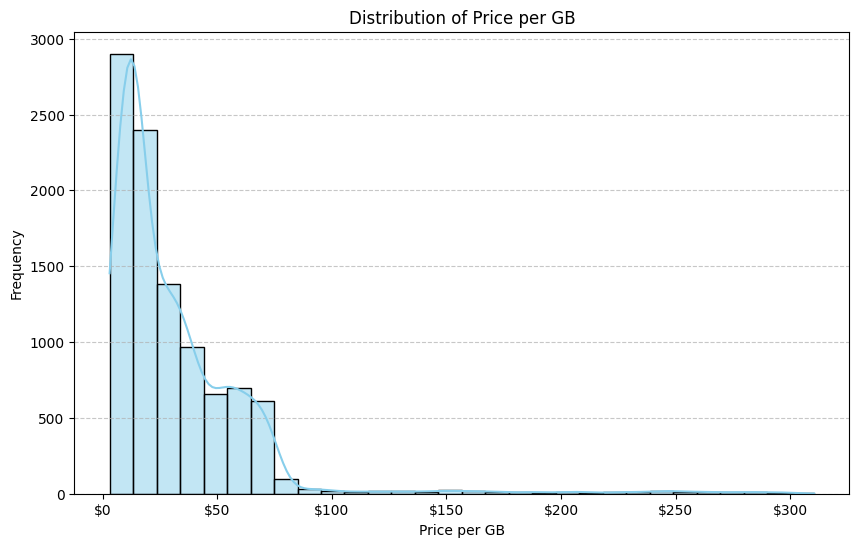

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["price_per_gb"], bins=30, kde=True, color= "skyblue")
plt.title("Distribution of Price per GB")
plt.xlabel("Price per GB")
plt.ylabel("Frequency")
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%0.0f'))
plt.grid(axis='y',  linestyle='--', alpha=0.7)
plt.show()

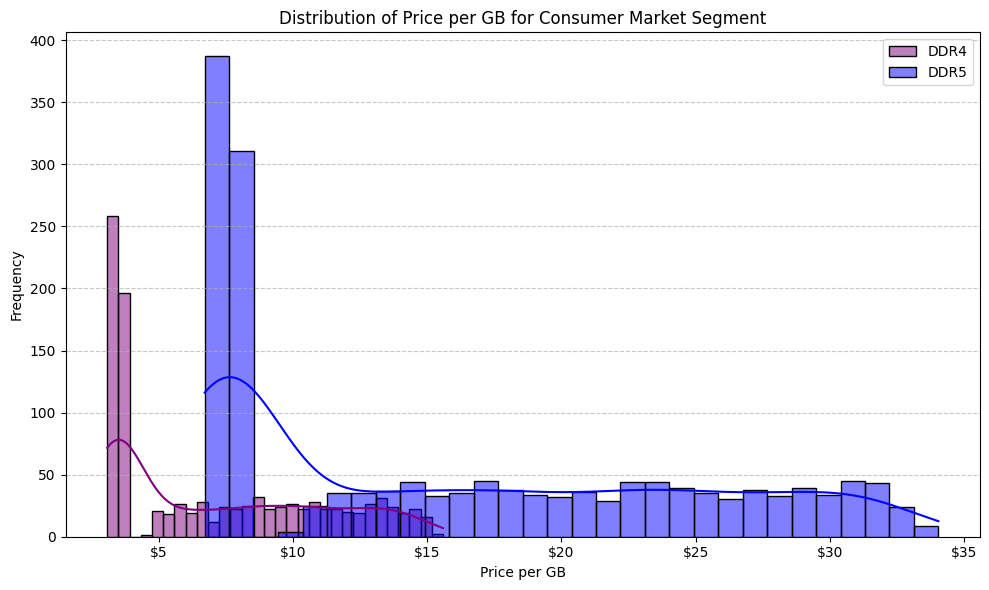

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## Filtering out so market segment only has consumer, no "future" DDR6 RAM
## or predicted data after April 2026

cm_df = df[(df['market_segment'] == 'Consumer') & ((df['generation'] == 'DDR4') |
  (df['generation'] == 'DDR5')) & (df['timestamp'] <= '2026-04-30')].copy()

#making 2 new datasets seperately for DDR4 and 5
r4_df = cm_df[cm_df['generation'] == 'DDR4'].copy()
r5_df = cm_df[cm_df['generation'] == 'DDR5'].copy()


plt.figure(figsize=(10, 6))
sns.histplot(r4_df['price_per_gb'], bins=30, label="DDR4", kde=True, color='purple')
sns.histplot(r5_df['price_per_gb'], bins=30, label="DDR5", kde=True, color='blue')
plt.title('Distribution of Price per GB for Consumer Market Segment')
plt.xlabel('Price per GB')
plt.ylabel('Frequency')
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%0.0f'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()

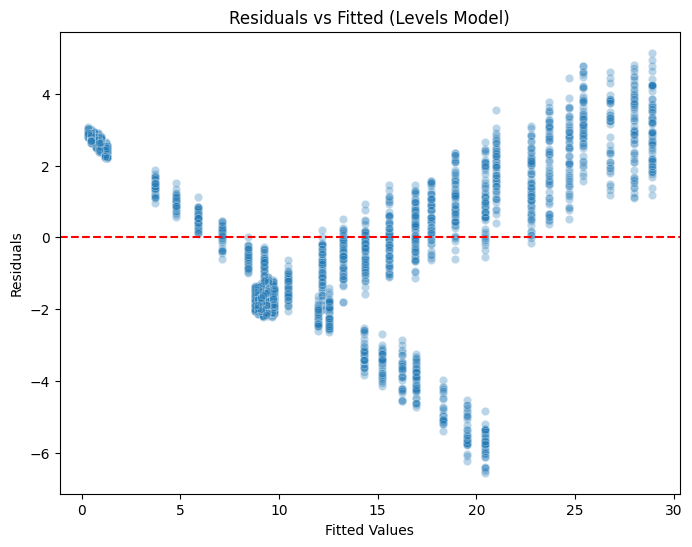

In [ ]:


#Adding binary if RAM is DDR4 or 5, and month
cm_df['is_ddr5'] = (cm_df['generation'] == 'DDR5').astype(int)
cm_df['month'] = cm_df['timestamp'].dt.to_period('M').astype(str)
cm_df['date'] = cm_df['timestamp']

base_model = smf.ols(
    "price_per_gb ~ is_ddr5 + C(month)",
    data=cm_df
).fit()

#adding residual and fitted columns
cm_df['resid'] = base_model.resid
cm_df['fitted'] = base_model.fittedvalues



plt.figure(figsize=(8,6))
sns.scatterplot(
    x=cm_df['fitted'],
    y=cm_df['resid'],
    alpha=0.3
)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Levels Model)")
plt.show()


# 3: Difference in Difference Model


In [ ]:
# Adding a log transformation column for pricing
cm_df['price_per_gb_log'] = np.log(cm_df['price_per_gb'])


# Adding a the period starting in June
shock_start = pd.to_datetime("2025-01-01")
cm_df['post_shock'] = (cm_df['timestamp'] >= shock_start).astype(int)

#Interaction effect creation
cm_df['interaction'] = cm_df['is_ddr5'] * cm_df['post_shock']

cm_df = cm_df.set_index(['kit_id', 'timestamp'])

In [ ]:
model = PanelOLS.from_formula(
    "price_per_gb_log ~ interaction + TimeEffects",
    data=cm_df
)

results = model.fit(
    cov_type='clustered',
    cluster_entity=True
)

print(results.summary)
#Taking parameter estimate and converting to percentage
print("The percent increase relatively is", np.exp(.7823) - 1)

                          PanelOLS Estimation Summary                           
Dep. Variable:       price_per_gb_log   R-squared:                        0.5480
Estimator:                   PanelOLS   R-squared (Between):              0.2520
No. Observations:                2644   R-squared (Within):               0.0000
Date:                Fri, May 15 2026   R-squared (Overall):              0.2520
Time:                        18:55:33   Log-likelihood                    317.19
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2221.4
Entities:                        2644   P-value                           0.0000
Avg Obs:                       1.0000   Distribution:                  F(1,1832)
Min Obs:                       1.0000                                           
Max Obs:                       1.0000   F-statistic (robust):          1.676e+05
                            

#4 Difference-in-Difference DDR4 vs. DDR5 visualized

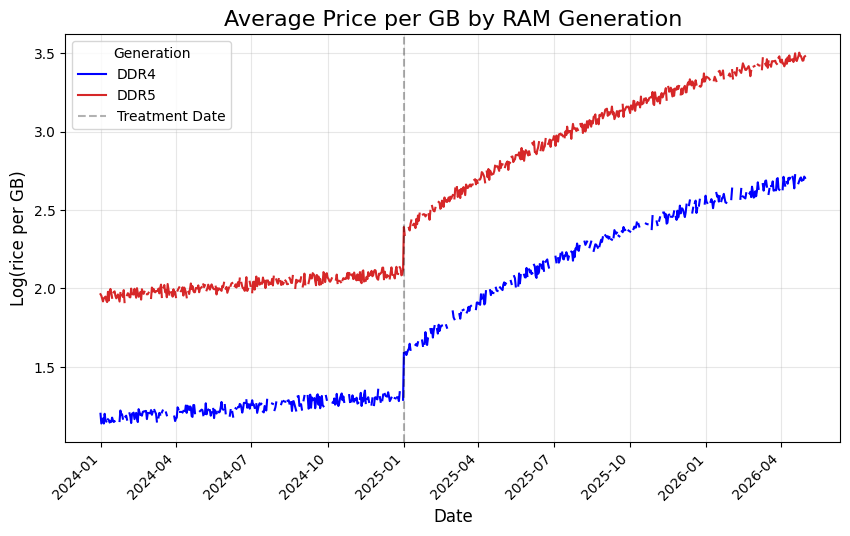

In [ ]:
#Grouping price by generation and time, then getting the mean.
ram_gen = (
    cm_df
    .groupby(['date', 'generation'])['price_per_gb_log']
    .mean()
    .unstack()
)


treatment_date = '2025-01-01'

# Making axis/plot
ax = ram_gen.plot(figsize=(10, 6),
                  color={'DDR4': 'blue', 'DDR5': '#d62728'})

#adding visualization for treatment date
ax.axvline(
    x=treatment_date,
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.3,
    label='Treatment Date'
)


ax.set_title('Average Price per GB by RAM Generation', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Log(rice per GB)', fontsize=12)
ax.legend(title= "Generation")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)


plt.show()

# 5: DiD Model of High vs Low Capacity

In [ ]:
# Adding higher capacity greater or equal to 32 and new interaction effect
cm_df['high_capacity'] = (cm_df['capacity_gb'] >= 32).astype(int)
cm_df['interaction_cap'] = cm_df['high_capacity'] * cm_df['post_shock']

model2_cap = PanelOLS.from_formula(
    "price_per_gb_log ~ interaction_cap + TimeEffects",
    data=cm_df
)

results2_cap = model2_cap.fit(
    cov_type='clustered',
    cluster_entity=True
)


print(results2_cap.summary)

print("The percent increase relatively is", np.exp(.2777) - 1)

                          PanelOLS Estimation Summary                           
Dep. Variable:       price_per_gb_log   R-squared:                        0.0736
Estimator:                   PanelOLS   R-squared (Between):              0.0820
No. Observations:                2644   R-squared (Within):               0.0000
Date:                Fri, May 15 2026   R-squared (Overall):              0.0820
Time:                        18:55:34   Log-likelihood                   -631.65
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      145.50
Entities:                        2644   P-value                           0.0000
Avg Obs:                       1.0000   Distribution:                  F(1,1832)
Min Obs:                       1.0000                                           
Max Obs:                       1.0000   F-statistic (robust):             144.20
                            

# 6: DiD Model of interaction effect

Testing whether high capacity DDR5 kits had a significant relative increase in price per gigabyte against all other RAM kits.

In [ ]:
# Interaction effect (Post shock x high capacity x generation)
cm_df['interaction_cap3'] = cm_df['high_capacity'] * cm_df['post_shock'] * cm_df['is_ddr5']

model3_cap = PanelOLS.from_formula(
    "price_per_gb_log ~ interaction_cap3 + TimeEffects",
    data=cm_df
)

results3_cap = model3_cap.fit(
    cov_type='clustered',
    cluster_entity=True
)
print(results3_cap.summary)

print("The percent increase relatively is", np.exp(.5233) - 1)

                          PanelOLS Estimation Summary                           
Dep. Variable:       price_per_gb_log   R-squared:                        0.2629
Estimator:                   PanelOLS   R-squared (Between):              0.1220
No. Observations:                2644   R-squared (Within):               0.0000
Date:                Fri, May 15 2026   R-squared (Overall):              0.1220
Time:                        18:58:49   Log-likelihood                   -329.37
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      653.53
Entities:                        2644   P-value                           0.0000
Avg Obs:                       1.0000   Distribution:                  F(1,1832)
Min Obs:                       1.0000                                           
Max Obs:                       1.0000   F-statistic (robust):             1011.8
                            

#7: DiD model DDR4 vs DDR5 (region by month fixed effects)

#

In [ ]:
# Creating a new column for region and time (region x month  interaction variable)
cm_df['region_time'] = (
    cm_df.reset_index()['region'].astype(str) # resetting index back into string
    + "_" +
    cm_df.reset_index()['timestamp'].dt.to_period('M').astype(str)
).values


model4 = PanelOLS.from_formula(
    "price_per_gb_log ~ interaction + C(region_time)",
    data=cm_df
)

results4 = model4.fit(
    cov_type='clustered',
    cluster_entity=True
)

print(results4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       price_per_gb_log   R-squared:                        0.8676
Estimator:                   PanelOLS   R-squared (Between):              0.8676
No. Observations:                2644   R-squared (Within):               0.0000
Date:                Fri, May 15 2026   R-squared (Overall):              0.8676
Time:                        19:04:38   Log-likelihood                   -51.227
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      96.567
Entities:                        2644   P-value                           0.0000
Avg Obs:                       1.0000   Distribution:                F(168,2475)
Min Obs:                       1.0000                                           
Max Obs:                       1.0000   F-statistic (robust):           6.66e+04
                            